## THE INTENT IS TO SEE THE CORRELATION BETWEEN SENSOR VALUES AND PASS/FAIL OF THE PROCESSING.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

In [2]:
%%time
df3=pd.read_csv("sub_numeric.csv",nrows=40000)

CPU times: user 2.21 s, sys: 321 ms, total: 2.54 s
Wall time: 2.57 s


In [3]:
df3.drop(columns=['Unnamed: 0'], axis=1,inplace=True)

In [4]:
df3.set_index("Id",inplace=True)

### LET'S COUNT THE TOTAL NUMBER OF POSITIVE, NEGATIVE, AND ZERO VALUES FOR EACH ROW AND KEEP THOSE AS NEW COLUMNS

In [5]:
%%time
negs=[]
for each in df3.index:
    neg=len(list(filter(lambda x: (x < 0),df3.loc[each]))) 
    negs.append(neg)

CPU times: user 26.3 s, sys: 24 ms, total: 26.3 s
Wall time: 26.4 s


In [6]:
%%time
pos=[]
for each in df3.index:
    ppos=len(list(filter(lambda x: (x > 0),df3.loc[each]))) 
    pos.append(ppos)

CPU times: user 26.8 s, sys: 11.6 ms, total: 26.8 s
Wall time: 26.8 s


In [7]:
%%time
zeros=[]
for each in df3.index:
    zer=len(list(filter(lambda x: (x == 0),df3.loc[each]))) 
    zeros.append(zer)

CPU times: user 26.8 s, sys: 9.53 ms, total: 26.8 s
Wall time: 26.8 s


In [8]:
df3

,L0_S0_F0,L0_S0_F2,L0_S0_F4,L0_S0_F6,L0_S0_F8,L0_S0_F10,L0_S0_F12,L0_S0_F14,L0_S0_F16,L0_S0_F18,...,L3_S50_F4245,L3_S50_F4247,L3_S50_F4249,L3_S50_F4251,L3_S50_F4253,L3_S51_F4256,L3_S51_F4258,L3_S51_F4260,L3_S51_F4262,Response
Id,,,,,,,,,,,,,,,,,,,,,
4,0.030,-0.034,-0.197,-0.179,0.118,0.116,-0.015,-0.032,0.020,0.083,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
7,0.088,0.086,0.003,-0.052,0.161,0.025,-0.015,-0.072,-0.225,-0.147,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
9,-0.036,-0.064,0.294,0.330,0.074,0.161,0.022,0.128,-0.026,-0.046,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
11,-0.055,-0.086,0.294,0.330,0.118,0.025,0.030,0.168,-0.169,-0.099,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
80086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
80088,-0.245,-0.317,-0.197,-0.161,-0.013,0.070,0.045,0.248,-0.163,-0.137,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [9]:
df3copy=df3[df3.columns[:-1]]

In [10]:
df3copy

,L0_S0_F0,L0_S0_F2,L0_S0_F4,L0_S0_F6,L0_S0_F8,L0_S0_F10,L0_S0_F12,L0_S0_F14,L0_S0_F16,L0_S0_F18,...,L3_S50_F4243,L3_S50_F4245,L3_S50_F4247,L3_S50_F4249,L3_S50_F4251,L3_S50_F4253,L3_S51_F4256,L3_S51_F4258,L3_S51_F4260,L3_S51_F4262
Id,,,,,,,,,,,,,,,,,,,,,
4,0.030,-0.034,-0.197,-0.179,0.118,0.116,-0.015,-0.032,0.020,0.083,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.088,0.086,0.003,-0.052,0.161,0.025,-0.015,-0.072,-0.225,-0.147,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,-0.036,-0.064,0.294,0.330,0.074,0.161,0.022,0.128,-0.026,-0.046,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,-0.055,-0.086,0.294,0.330,0.118,0.025,0.030,0.168,-0.169,-0.099,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80088,-0.245,-0.317,-0.197,-0.161,-0.013,0.070,0.045,0.248,-0.163,-0.137,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df3copy[~df3copy.isnull()] = 1  # not nan

In [12]:
df3copy

,L0_S0_F0,L0_S0_F2,L0_S0_F4,L0_S0_F6,L0_S0_F8,L0_S0_F10,L0_S0_F12,L0_S0_F14,L0_S0_F16,L0_S0_F18,...,L3_S50_F4243,L3_S50_F4245,L3_S50_F4247,L3_S50_F4249,L3_S50_F4251,L3_S50_F4253,L3_S51_F4256,L3_S51_F4258,L3_S51_F4260,L3_S51_F4262
Id,,,,,,,,,,,,,,,,,,,,,
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80088,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df3copy=df3copy.fillna(0)

In [14]:
df3copy

,L0_S0_F0,L0_S0_F2,L0_S0_F4,L0_S0_F6,L0_S0_F8,L0_S0_F10,L0_S0_F12,L0_S0_F14,L0_S0_F16,L0_S0_F18,...,L3_S50_F4243,L3_S50_F4245,L3_S50_F4247,L3_S50_F4249,L3_S50_F4251,L3_S50_F4253,L3_S51_F4256,L3_S51_F4258,L3_S51_F4260,L3_S51_F4262
Id,,,,,,,,,,,,,,,,,,,,,
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80085,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
80086,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
80088,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
%%time
properties=[]
for each in df3copy.index:
    a=df3copy.loc[each].tolist()
    strings=[str(int(each)) for each in a]
    a_string = "".join(strings)
    properties.append(a_string)

CPU times: user 15.5 s, sys: 15.7 ms, total: 15.6 s
Wall time: 15 s


In [16]:
%%time
df3["sum"]=df3.sum(axis=1)

CPU times: user 996 ms, sys: 228 ms, total: 1.22 s
Wall time: 489 ms


In [17]:
df3["products"]=properties
df3["zero"]=zeros
df3["neg"]=negs
df3["pos"]=pos

In [18]:
del df3copy
del zeros
del pos
del negs

In [19]:
df3

,L0_S0_F0,L0_S0_F2,L0_S0_F4,L0_S0_F6,L0_S0_F8,L0_S0_F10,L0_S0_F12,L0_S0_F14,L0_S0_F16,L0_S0_F18,...,L3_S51_F4256,L3_S51_F4258,L3_S51_F4260,L3_S51_F4262,Response,sum,products,zero,neg,pos
Id,,,,,,,,,,,,,,,,,,,,,
4,0.030,-0.034,-0.197,-0.179,0.118,0.116,-0.015,-0.032,0.020,0.083,...,NaN,NaN,NaN,NaN,0,-3.215,1111111111111111111111100000000011000001111110...,30,74,59
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,0.451,0000000000000000000000000000000000000000000000...,39,82,72
7,0.088,0.086,0.003,-0.052,0.161,0.025,-0.015,-0.072,-0.225,-0.147,...,NaN,NaN,NaN,NaN,0,-0.130,1111111111111111111111100000000000111110001110...,41,69,81
9,-0.036,-0.064,0.294,0.330,0.074,0.161,0.022,0.128,-0.026,-0.046,...,NaN,NaN,NaN,NaN,0,-0.123,1111111111111111111111100000000011000001111110...,39,73,79
11,-0.055,-0.086,0.294,0.330,0.118,0.025,0.030,0.168,-0.169,-0.099,...,NaN,NaN,NaN,NaN,0,-1.453,1111111111111100000000011111111111000001111110...,40,82,69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,-1.482,0000000000000000000000000000000000000000000000...,40,90,81
80086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,3.797,0000000000000000000000000000000000000000000000...,39,52,102
80088,-0.245,-0.317,-0.197,-0.161,-0.013,0.070,0.045,0.248,-0.163,-0.137,...,NaN,NaN,NaN,NaN,0,-2.202,1111111111111111111111100000000011001110001110...,41,77,73


In [20]:
propertySet=list(set(properties))

In [21]:
res0=df3[df3["Response"]==0]["products"].tolist()
res0=set(res0)

In [22]:
res1=df3[df3["Response"]==1]["products"].tolist()
res1=set(res1)

In [23]:
common=res0.intersection(res1)

In [24]:
common=list(common)

In [25]:
%%time
lens={}
for each in common:
    lens[each]=len(df3[df3["products"]==each])

CPU times: user 959 ms, sys: 3.85 ms, total: 963 ms
Wall time: 962 ms


In [26]:
sortedVals=sorted(lens.items(),key=lambda x:x[1],reverse=True)

In [27]:
sortedVals[0][0]

'00000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000011111111111111000000000000000111111111111111000000000111111111111111111110000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000011111111111111000000000000000000000000000011111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111110000011111111111111111111110000000011110000000000000000000000000000000000000000000000000000000000000000000000000000000000000'

In [28]:
df3["results"]=np.nan
df3["results"][df3["Response"]==0]="Pass"
df3["results"][df3["Response"]==1]="Fail"
df3

,L0_S0_F0,L0_S0_F2,L0_S0_F4,L0_S0_F6,L0_S0_F8,L0_S0_F10,L0_S0_F12,L0_S0_F14,L0_S0_F16,L0_S0_F18,...,L3_S51_F4258,L3_S51_F4260,L3_S51_F4262,Response,sum,products,zero,neg,pos,results
Id,,,,,,,,,,,,,,,,,,,,,
4,0.030,-0.034,-0.197,-0.179,0.118,0.116,-0.015,-0.032,0.020,0.083,...,NaN,NaN,NaN,0,-3.215,1111111111111111111111100000000011000001111110...,30,74,59,Pass
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,0.451,0000000000000000000000000000000000000000000000...,39,82,72,Pass
7,0.088,0.086,0.003,-0.052,0.161,0.025,-0.015,-0.072,-0.225,-0.147,...,NaN,NaN,NaN,0,-0.130,1111111111111111111111100000000000111110001110...,41,69,81,Pass
9,-0.036,-0.064,0.294,0.330,0.074,0.161,0.022,0.128,-0.026,-0.046,...,NaN,NaN,NaN,0,-0.123,1111111111111111111111100000000011000001111110...,39,73,79,Pass
11,-0.055,-0.086,0.294,0.330,0.118,0.025,0.030,0.168,-0.169,-0.099,...,NaN,NaN,NaN,0,-1.453,1111111111111100000000011111111111000001111110...,40,82,69,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,-1.482,0000000000000000000000000000000000000000000000...,40,90,81,Pass
80086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,3.797,0000000000000000000000000000000000000000000000...,39,52,102,Pass
80088,-0.245,-0.317,-0.197,-0.161,-0.013,0.070,0.045,0.248,-0.163,-0.137,...,NaN,NaN,NaN,0,-2.202,1111111111111111111111100000000011001110001110...,41,77,73,Pass


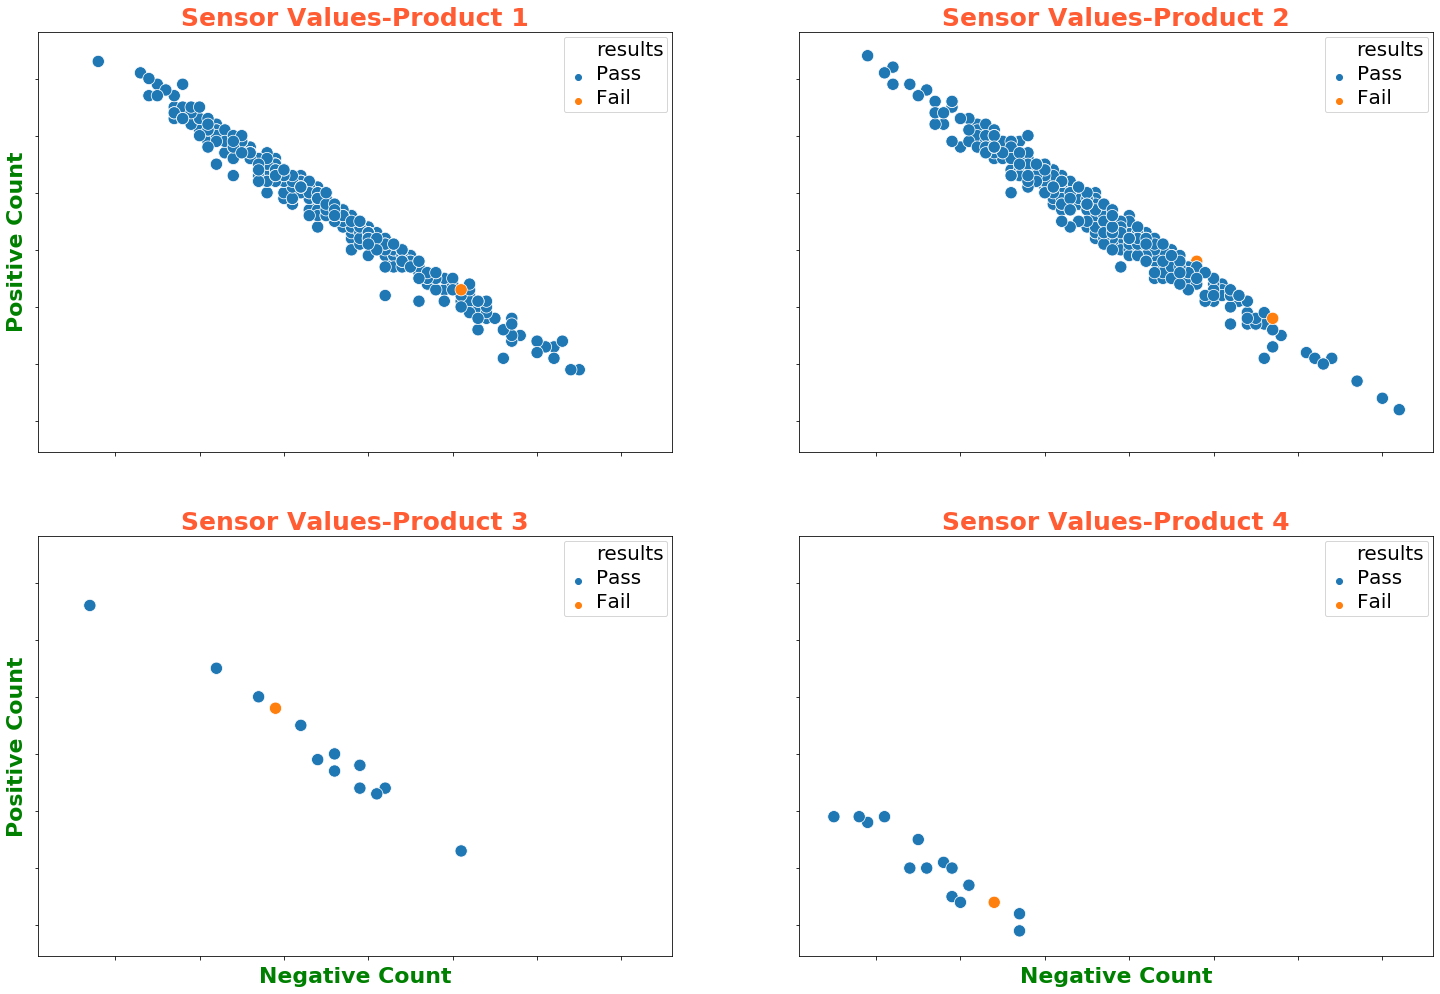

In [29]:
nrows=2
ncols=2
fig,ax=plt.subplots(nrows=nrows,ncols=ncols,figsize=(25,17),sharex=True,sharey=True)

def lineDetails(temp,i,j,xlabel,ylabel,tittle):
    g=sns.scatterplot(data=temp,y="pos",x="neg",ax=ax[i,j],hue="results",s=150)
    ax[i,j].set_xlabel(xlabel,fontsize=22,fontweight='bold',color='green')
    ax[i,j].set_ylabel(ylabel,fontsize=22,fontweight='bold',color='green')
    ax[i,j].set_title(tittle,fontsize=25,fontweight="bold",color="#ff5c33")
    plt.draw()
    ax[i,j].set_xticklabels(ax[i,j].get_xticklabels(),fontsize=19,fontweight="bold")
    ax[i,j].set_yticklabels(ax[i,j].get_yticklabels(),fontsize=19,fontweight="bold")
    plt.setp(g.get_legend().get_texts(),fontsize=20) 
    plt.setp(g.get_legend().get_title(),fontsize=25) 

    
lineDetails(df3[df3["products"]==sortedVals[0][0]],0,0,"Negative Count",
            "Positive Count","Sensor Values-Product 1")
lineDetails(df3[df3["products"]==sortedVals[1][0]],0,1,"Negative Count",
            "Positive Count","Sensor Values-Product 2")
lineDetails(df3[df3["products"]==sortedVals[100][0]],1,0,"Negative Count",
            "Positive Count","Sensor Values-Product 3")
lineDetails(df3[df3["products"]==sortedVals[-50][0]],1,1,"Negative Count",
            "Positive Count","Sensor Values-Product 4")

In [30]:
df3["Response"].value_counts()

0    39781
1      219
Name: Response, dtype: int64

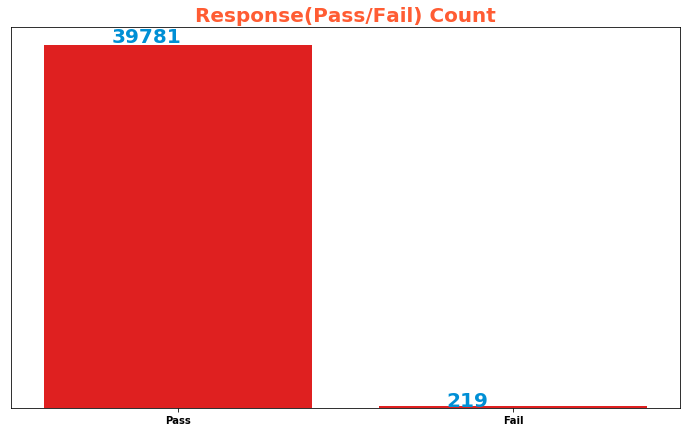

In [31]:
g=sns.barplot(y=[df3["Response"].value_counts()[0],df3["Response"].value_counts()[1]],
           x=["Pass","Fail"],color="red")
k=0
for p in g.patches:
    height=p.get_height()
    length=p.get_x()+p.get_width()/4
    g.text(length,1.01*height,df3["Response"].value_counts()[k],
            size=20,color='#008FD5',weight="bold")
    k+=1

g.set(yticks=[])
plt.draw()
plt.gcf().set_size_inches(12,7)
plt.xticks(fontweight="bold")
plt.title("Response(Pass/Fail) Count",fontsize=20,color="#ff5c33",fontweight="bold")
plt.show()